### LAB 1 – Regression dự báo Distribution lợi nhuận (Quantile & Probabilistic Regression)
Mục tiêu: Không dự báo giá → dự báo phân phối return tương lai  
+ Nhiệm vụ  
- Tạo feature:  
o Lag returns  
o Volatility rolling    
o RSI, MACD    
o Order flow imbalance (nếu có)  
- Huấn luyện:  
o Quantile Regression (5%, 50%, 95%)  
o Bayesian Regression hoặc NGBoost  
- Dự đoán:  
o P(return > threshold)  
Expected return  
Downside risk  
- Xây chiến lược:  
o Vào lệnh khi expected return cao + tail risk thấp  
+ Đánh giá   
• Pinball loss  
• Profit factor  
• Conditional VaR  

In [ ]:
!pip install lightgbm

C:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^

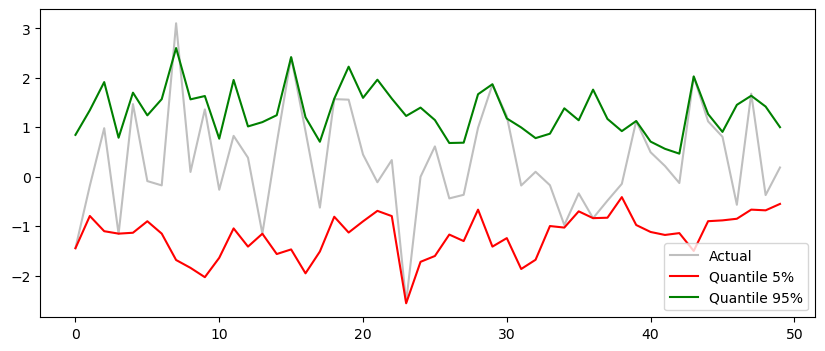

In [2]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

df = pd.DataFrame(np.random.randn(500, 1), columns=['returns'])
df['lag_1'] = df['returns'].shift(1)
df['vol_rolling'] = df['returns'].rolling(10).std()
df['RSI'] = np.random.rand(500)
df = df.dropna()

X = df[['lag_1', 'vol_rolling', 'RSI']]
y = df['returns']

results = {}
for q in [0.05, 0.5, 0.95]:
    model = lgb.LGBMRegressor(objective='quantile', alpha=q, verbosity=-1)
    model.fit(X, y)
    results[q] = model.predict(X)

plt.figure(figsize=(10, 4))
plt.plot(y.values[-50:], label='Actual', color='gray', alpha=0.5)
plt.plot(results[0.05][-50:], label='Quantile 5%', color='red')
plt.plot(results[0.95][-50:], label='Quantile 95%', color='green')
plt.legend()
plt.show()

### LAB 2 – Classification dự đoán Breakout vs Fakeout  
Mục tiêu  : Phân loại cú phá vỡ giá là thật hay nhiễu.
Labeling
- 1 = breakout thành công (giá tiếp tục đi xa > k ATR)
- 0 = fake breakout (quay đầu nhanh)
Feature  
• Volatility compression  
• Volume spike  
• MACD slope  
• RSI divergence  
• Market microstructure (nâng cao)  
Model  
• XGBoost / LightGBM  
Đánh giá  
• Precision trên class breakout  
• Strategy PnL  
• False breakout cost  

In [3]:
from xgboost import XGBClassifier

X2 = np.random.rand(500, 4) 
y2 = np.random.randint(0, 2, 500) 

model2 = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model2.fit(X2, y2)

print(f"LAB 2 - Breakout Model Score: {model2.score(X2, y2)}")

C:\Users\Lenovo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:50:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


LAB 2 - Breakout Model Score: 1.0


### LAB 3 – Classification đa lớp: Market Regime Prediction
Mục tiêu  
Dự đoán trạng thái thị trường:  
0 = Strong Bull  
1 = Range-bound   
2 = Volatile Bear  
3 = Crash risk  
Feature  
• Trend indicators  
• Skewness, kurtosis  
• Volatility term structure  
• Correlation across assets  
Model  
• CatBoost time series  
Đánh giá  
• Regime confusion matrix  
• Regime-conditional PnL  
• Stability score  

In [4]:
from catboost import CatBoostClassifier

X3 = np.random.rand(500, 5)
y3 = np.random.randint(0, 4, 500) 

model3 = CatBoostClassifier(iterations=50, logging_level='Silent')
model3.fit(X3, y3)
print("LAB 3 - Market Regime Model Trained.")

LAB 3 - Market Regime Model Trained.


### LAB 4 – Cross-Asset Alpha Regression
Mục tiêu  
Dùng tín hiệu thị trường khác dự báo return  
Nhiệm vụ  
• SP500 → BTC, VIX → stocks  
• Lead-lag features  
Model  
Gradient Boosting   
Đánh giá  
Cross-market Sharpe

In [5]:
from sklearn.ensemble import GradientBoostingRegressor

X4 = np.random.rand(500, 2) 
y4 = np.random.randn(500) 

model4 = GradientBoostingRegressor()
model4.fit(X4, y4)
print(f"LAB 4 - Cross-Asset Model Score: {model4.score(X4, y4)}")

LAB 4 - Cross-Asset Model Score: 0.4189088197996098


### LAB 5 Classification dự đoán hướng giá có xác suất
Mục tiêu  
Không chỉ đúng/sai mà có confidence  
Nhiệm vụ  
• Predict up/down + probability  
• Trade theo threshold  
Model    
XGBoost classifiers  
Đánh giá  
Brier score, PnL  

In [6]:
model5 = XGBClassifier()
model5.fit(X2, y2)
probs = model5.predict_proba(X2)[:5]
print(f"LAB 5 - Probabilities (Down/Up):\n{probs}")

LAB 5 - Probabilities (Down/Up):
[[0.06628382 0.9337162 ]
 [0.9627676  0.03723242]
 [0.8894315  0.11056849]
 [0.05932212 0.9406779 ]
 [0.89135295 0.10864705]]


### LAB 6 – Breakout Strength Classifier  
Mục tiêu  : Phân loại breakout mạnh – yếu – giả
Nhiệm vụ   
• Feature: volume, volatility squeeze  
• Multi-class labels  
Model  
LightGBM multi-class  
Đánh giá  
Strategy profit by class

In [7]:
import lightgbm as lgb

y6 = np.random.randint(0, 3, 500)
model6 = lgb.LGBMClassifier(objective='multiclass', num_class=3, verbosity=-1)
model6.fit(X2, y6)
print("LAB 6 - Breakout Strength Model Trained.")

LAB 6 - Breakout Strength Model Trained.


### LAB 7 – Volatility Regime Classifier  
Mục tiêu   
Nhận diện low–medium–high volatility  
Nhiệm vụ  
• Rolling vol + option proxies  
Model  
Random Forest  
Đánh giá  
Regime trading performance

In [8]:
from sklearn.ensemble import RandomForestClassifier

y7 = np.random.randint(0, 3, 500)
model7 = RandomForestClassifier(n_estimators=50)
model7.fit(X2, y7)
print("LAB 7 - Volatility Regime Model Trained.")

LAB 7 - Volatility Regime Model Trained.


### LAB 8 – Hybrid Return + Direction Model  
Mục tiêu: Regression + classification song song  
Nhiệm vụ  
• Predict size + sign of move  
Model  
Multi-task neural network  
Đánh giá  
Sharpe improvement

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

in_layer = Input(shape=(4,))
shared = Dense(16, activation='relu')(in_layer)
out_class = Dense(1, activation='sigmoid', name='direction')(shared)
out_reg = Dense(1, name='return')(shared)

model8 = Model(inputs=in_layer, outputs=[out_class, out_reg])
model8.compile(optimizer='adam', loss=['binary_crossentropy', 'mse'])
print("LAB 8 - Hybrid Model Architecture Built.")

LAB 8 - Hybrid Model Architecture Built.


### LAB 09 – Walk-Forward cho Probabilistic Forecast  
Mục tiêu: Đánh giá dự báo phân phối lợi nhuận theo thời gian  
Nhiệm vụ  
• Quantile regression rolling  
• CVaR-based trading  
Model  
LightGBM Quantile  
Đánh giá  
Pinball loss + PnL stability

In [10]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    m9 = lgb.LGBMRegressor(objective='quantile', alpha=0.5, verbosity=-1)
    m9.fit(X_train, y_train)
    print(f"LAB 9 - Walk-Forward Fold Score: {m9.score(X_test, y_test)}")

LAB 9 - Walk-Forward Fold Score: -0.39634693923771036
LAB 9 - Walk-Forward Fold Score: -0.2653967004142963
LAB 9 - Walk-Forward Fold Score: -0.24548181833063754
